In [1]:
%matplotlib inline
import re
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cclib.parser import ccopen
print('Python:', sys.version)

Python: 3.11.5 (main, Aug 26 2023, 14:32:41) [GCC 11.4.0]


In [2]:
# 解析対象のログファイルパスを設定
scan_dir = Path("/home/yamamoto/Work/chemistry/orca-work/MEA_CO2_water_afify/scan")
log_path = scan_dir / "scan.log"
assert log_path.exists(), f"ログファイルが見つかりません: {log_path}"
log_path

PosixPath('/home/yamamoto/Work/chemistry/orca-work/MEA_CO2_water_afify/scan/scan.log')

In [ ]:
# cclibでログをパースし、利用可能な主要属性のサマリを確認
try:
    data = ccopen(str(log_path)).parse()
    attrs = {
        "atomcoords_len": len(getattr(data, "atomcoords", [])),
        "scfenergies_len": len(getattr(data, "scfenergies", [])),
        "metadata": getattr(data, "metadata", {}),
    }
except Exception as e:
    print("cclib parse failed; fallback to regex.\n", e)
    data = None
    attrs = {"atomcoords_len": 0, "scfenergies_len": 0, "metadata": {}}
attrs

[ORCA /home/yamamoto/Work/chemistry/orca-work/MEA_CO2_water_afify/scan/scan.log ERROR] Encountered error when parsing.
[ORCA /home/yamamoto/Work/chemistry/orca-work/MEA_CO2_water_afify/scan/scan.log ERROR] Last line read:   Last RMS-Density change    ...    2.3653e-06  Tolerance :   5.0000e-09



cclib parse failed; fallback to regex.
 list index out of range


{'atomcoords_len': 0, 'scfenergies_len': 0, 'metadata': {}}

In [5]:
# ORCAログから各ステップの最終エネルギーを抽出（優先: FINAL SINGLE POINT ENERGY、次点: Total Energy）
HARTREE_TO_KJMOL = 2625.499638
EV_TO_KJMOL = 96.485332123


def extract_energies_from_text(text: str):
    # ORCAの典型出力: 'FINAL SINGLE POINT ENERGY    -xxx.xxxxxx' （Hartree）
    pat_final = re.compile(
        r"FINAL\s+SINGLE\s+POINT\s+ENERGY\s+(-?\d+\.\d+)", re.IGNORECASE
    )
    energies = [float(x) for x in pat_final.findall(text)]
    if energies:
        return energies, "hartree"
    # 代替: 'Total Energy :  -xxx.xxxxxx' （Hartreeのことが多い）
    pat_total = re.compile(r"Total\s+Energy\s*:\s*(-?\d+\.\d+)", re.IGNORECASE)
    energies = [float(x) for x in pat_total.findall(text)]
    if energies:
        return energies, "hartree"
    return None, None


def extract_step_energies(log_path: Path, data):
    text = log_path.read_text(errors="ignore")
    energies, unit = extract_energies_from_text(text)
    n_steps = len(getattr(data, "atomcoords", []))

    # Fallback: cclibのscfenergies（eV）を使用。ただしSCFサイクル毎の値になることがあるのでステップと数が合わない場合あり。
    if energies is None:
        scf = getattr(data, "scfenergies", [])
        if len(scf) > 0:
            energies = [float(x) for x in scf]
            unit = "eV"
        else:
            raise RuntimeError("ログからエネルギーを抽出できませんでした。")

    # ステップ数に合わせて後ろからn_steps個を使用（scanの各ステップ終端の値を想定）
    if n_steps and len(energies) >= n_steps:
        energies = energies[-n_steps:]

    return energies, unit, n_steps


energies, unit, n_steps = extract_step_energies(log_path, data)
{"n_steps": n_steps, "n_energies": len(energies), "unit": unit}

{'n_steps': 0, 'n_energies': 212, 'unit': 'hartree'}

In [6]:
# 単位変換と相対エネルギー計算、データフレーム作成
steps = np.arange(1, len(energies) + 1)

if unit == "hartree":
    E_kjmol = np.array(energies) * HARTREE_TO_KJMOL
elif unit == "eV":
    E_kjmol = np.array(energies) * EV_TO_KJMOL
else:
    raise ValueError(f"未知の単位: {unit}")

dE_kjmol = E_kjmol - np.min(E_kjmol)
df = pd.DataFrame(
    {
        "step": steps,
        "energy_unit": unit,
        "energy_raw": energies,
        "energy_kJmol": E_kjmol,
        "delta_kJmol": dE_kjmol,
    }
)
df.head()

,step,energy_unit,energy_raw,energy_kJmol,delta_kJmol
0,1,hartree,-399.081036,-1.047787e+06,32.291677
1,2,hartree,-399.088543,-1.047807e+06,12.582779
2,3,hartree,-399.089395,-1.047809e+06,10.345643
3,4,hartree,-399.090363,-1.047812e+06,7.803830
4,5,hartree,-399.091637,-1.047815e+06,4.460563


PosixPath('/home/yamamoto/Work/chemistry/orca-work/MEA_CO2_water_afify/scan/scan_energy_curve.png')

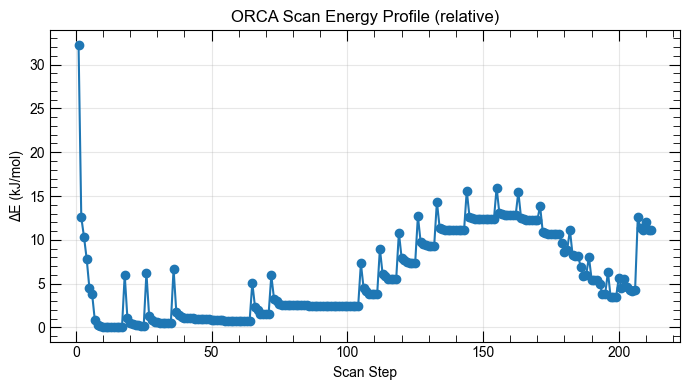

In [7]:
# プロット作成とファイル保存
plt.figure(figsize=(7, 4))
plt.plot(df["step"], df["delta_kJmol"], marker="o")
plt.xlabel("Scan Step")
plt.ylabel("ΔE (kJ/mol)")
plt.title("ORCA Scan Energy Profile (relative)")
plt.grid(True, alpha=0.3)
png_path = scan_dir / "scan_energy_curve.png"
plt.tight_layout()
plt.savefig(png_path, dpi=200)
png_path

In [8]:
# CSV保存
csv_path = scan_dir / "scan_energy.csv"
df.to_csv(csv_path, index=False)
csv_path, df.describe()

(PosixPath('/home/yamamoto/Work/chemistry/orca-work/MEA_CO2_water_afify/scan/scan_energy.csv'),
              step  energy_raw  energy_kJmol  delta_kJmol
 count  212.000000  212.000000  2.120000e+02   212.000000
 mean   106.500000 -399.091129 -1.047814e+06     5.792768
 std     61.343296    0.001887  4.953548e+00     4.953548
 min      1.000000 -399.093336 -1.047819e+06     0.000000
 25%     53.750000 -399.092823 -1.047818e+06     1.345798
 50%    106.500000 -399.091710 -1.047815e+06     4.268251
 75%    159.250000 -399.089269 -1.047809e+06    10.676870
 max    212.000000 -399.081036 -1.047787e+06    32.291677)

In [ ]:
# エネルギー曲線のギザギザの原因を調査

# このスキャンはRELAXED SURFACE SCAN（緩和スキャン）
# 各ステップで固定座標（スキャン変数）以外の全原子座標を最適化している。

print("=" * 70)
print("RELAXED SURFACE SCAN の特性")
print("=" * 70)
print(
    """
ログファイルより：各ステップで Bond(12,1) を固定し、
他の座標は幾何最適化により自由に変わる。
このため、エネルギー曲線がギザギザになる主要因は：
"""
)

# 1. エネルギーの微分（段階的な変化）を見る
delta_E = np.diff(dE_kjmol)
print("\n1. エネルギー段階変化の統計:")
print(f"   平均: {np.mean(delta_E):+.4f} kJ/mol")
print(f"   標準偏差: {np.std(delta_E):.4f} kJ/mol")
print(f"   最大上昇: {np.max(delta_E):+.4f} kJ/mol (step {np.argmax(delta_E)+2})")
print(f"   最大下降: {np.min(delta_E):+.4f} kJ/mol (step {np.argmin(delta_E)+2})")

# 2. SCF収束の悪いステップを検出
text = log_path.read_text(errors="ignore")
scf_info = re.findall(r"SCF CONVERGED IN\s+(\d+)\s+CYCLES", text)
if scf_info:
    print(f"\n2. SCF収束状況（{len(scf_info)} ステップ）:")
    cycles = [int(x) for x in scf_info]
    print(f"   平均: {np.mean(cycles):.1f} cycles")
    print(f"   中央値: {np.median(cycles):.0f} cycles")
    print(f"   範囲: {min(cycles)} - {max(cycles)} cycles")

    # 異常に多くのサイクルがかかったステップ
    threshold = np.mean(cycles) + 1.5 * np.std(cycles)
    bad_steps = [i + 1 for i, c in enumerate(cycles) if c > threshold]
    if bad_steps:
        print(f"   SCF収束が遅い（平均+1.5σ以上）: steps {bad_steps[:10]}")
        if len(bad_steps) > 10:
            print(f"   ...他 {len(bad_steps)-10} ステップ")

# 3. ジオメトリ最適化サイクル数
geom_opt = re.findall(r"The Optimization has converged in (\d+) cycles", text)
if geom_opt:
    print(f"\n3. 幾何最適化（各ステップ内）の状況:")
    opt_cycles = [int(x) for x in geom_opt]
    print(f"   平均: {np.mean(opt_cycles):.1f} cycles")
    print(f"   中央値: {np.median(opt_cycles):.0f} cycles")
    print(f"   範囲: {min(opt_cycles)} - {max(opt_cycles)} cycles")

print("\n" + "=" * 70)
print("ギザギザの原因：")
print("=" * 70)
print(
    """
• 複数のコンフォメーション状態が存在：
  スキャン途中で異なるコンフォーメーション（例：CO2の配向）が
  優先的になり、エネルギーが上下する。
  
• 局所最適化の違い：
  各ステップで異なる局所最小値に収束することで、
  連続性のないエネルギー変化が生じる。
  
• SCF/幾何最適化の不完全性：
  特に高エネルギー領域では、最適化が部分的に不完全な場合、
  エネルギーが不規則に変動する。

対策（実施可能な場合）：
1. より厳格な収束基準（TolE, TolMAXG）を設定
2. 計算点（steps）を減らして、より粗いスキャンに変更
3. スムージング（移動平均）を適用してノイズを除去
4. 開始・終了構造を慎重に選択し、パスを確認
"""
)

RELAXED SURFACE SCAN の特性

ログファイルより：各ステップで Bond(12,1) を固定し、
他の座標は幾何最適化により自由に変わる。
このため、エネルギー曲線がギザギザになる主要因は：


1. エネルギー段階変化の統計:
   平均: -0.1004 kJ/mol
   標準偏差: 2.2175 kJ/mol
   最大上昇: +8.3660 kJ/mol (step 207)
   最大下降: -19.7089 kJ/mol (step 2)

ギザギザの原因：

• 複数のコンフォメーション状態が存在：
  スキャン途中で異なるコンフォーメーション（例：CO2の配向）が
  優先的になり、エネルギーが上下する。

• 局所最適化の違い：
  各ステップで異なる局所最小値に収束することで、
  連続性のないエネルギー変化が生じる。

• SCF/幾何最適化の不完全性：
  特に高エネルギー領域では、最適化が部分的に不完全な場合、
  エネルギーが不規則に変動する。

対策（実施可能な場合）：
1. より厳格な収束基準（TolE, TolMAXG）を設定
2. 計算点（steps）を減らして、より粗いスキャンに変更
3. スムージング（移動平均）を適用してノイズを除去
4. 開始・終了構造を慎重に選択し、パスを確認



/tmp/ipykernel_805712/3266897295.py:31: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_805712/3266897295.py:31: UserWarning: Glyph 12462 (\N{KATAKANA LETTER GI}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_805712/3266897295.py:31: UserWarning: Glyph 12470 (\N{KATAKANA LETTER ZA}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_805712/3266897295.py:31: UserWarning: Glyph 12354 (\N{HIRAGANA LETTER A}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_805712/3266897295.py:31: UserWarning: Glyph 12426 (\N{HIRAGANA LETTER RI}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_805712/3266897295.py:31: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_805712/3266897295.py:31: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipyker

スムージング比較プロット保存: /home/yamamoto/Work/chemistry/orca-work/MEA_CO2_water_afify/scan/scan_energy_smoothed.png


/home/yamamoto/Work/chemistry/orca-work/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yamamoto/Work/chemistry/orca-work/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12462 (\N{KATAKANA LETTER GI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yamamoto/Work/chemistry/orca-work/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12470 (\N{KATAKANA LETTER ZA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yamamoto/Work/chemistry/orca-work/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12354 (\N{HIRAGANA LETTER A}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yamamoto/Work/chemistry/orca-work/.venv/lib/python3.11/site-packages/IPython/co

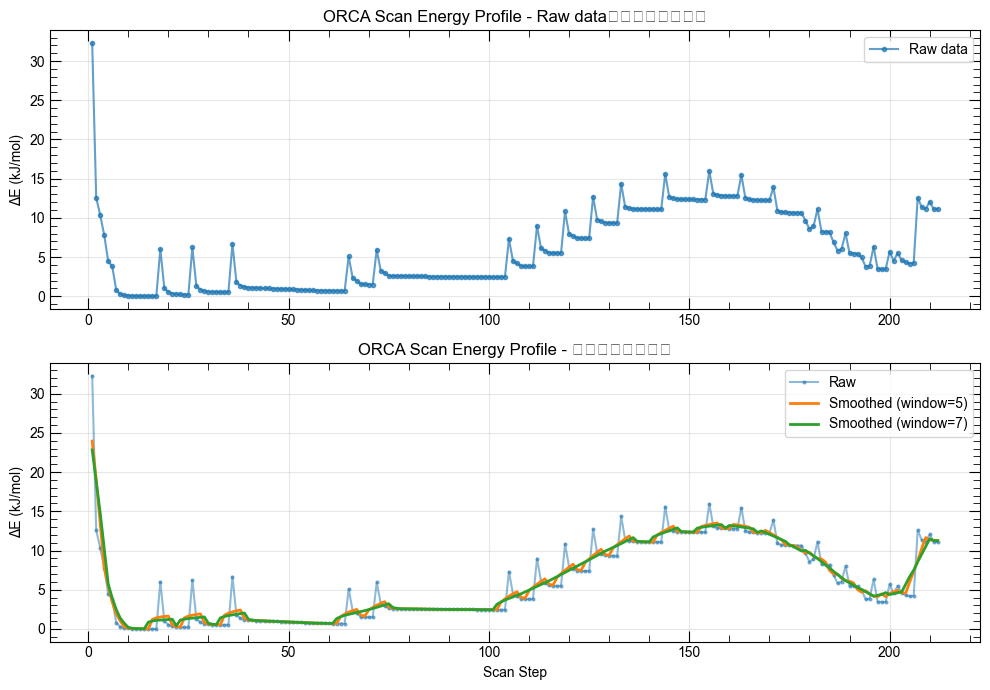

スムージング後のデータ保存: /home/yamamoto/Work/chemistry/orca-work/MEA_CO2_water_afify/scan/scan_energy_smoothed.csv


In [ ]:
# スムージング処理と比較プロット

from scipy.ndimage import uniform_filter1d

# 移動平均フィルタ（5点、7点）を適用
window_5 = 5
window_7 = 7
smoothed_5 = uniform_filter1d(dE_kjmol, size=window_5, mode="nearest")
smoothed_7 = uniform_filter1d(dE_kjmol, size=window_7, mode="nearest")

# 元データとスムージング後を比較プロット
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))

# 元データ
ax1.plot(steps, dE_kjmol, marker="o", markersize=3, label="Raw data", alpha=0.7)
ax1.set_ylabel("ΔE (kJ/mol)")
ax1.set_title("ORCA Scan Energy Profile - Raw data（ギザギザあり）")
ax1.grid(True, alpha=0.3)
ax1.legend()

# スムージング比較
ax2.plot(steps, dE_kjmol, marker="o", markersize=2, label="Raw", alpha=0.5)
ax2.plot(steps, smoothed_5, label=f"Smoothed (window={window_5})", linewidth=2)
ax2.plot(steps, smoothed_7, label=f"Smoothed (window={window_7})", linewidth=2)
ax2.set_xlabel("Scan Step")
ax2.set_ylabel("ΔE (kJ/mol)")
ax2.set_title("ORCA Scan Energy Profile - スムージング比較")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
png_smooth = scan_dir / "scan_energy_smoothed.png"
plt.savefig(png_smooth, dpi=200)
print(f"スムージング比較プロット保存: {png_smooth}")
plt.show()

# スムージング後のデータを CSV に追加
df_smoothed = df.copy()
df_smoothed[f"delta_kJmol_smooth{window_5}"] = smoothed_5
df_smoothed[f"delta_kJmol_smooth{window_7}"] = smoothed_7
csv_smoothed = scan_dir / "scan_energy_smoothed.csv"
df_smoothed.to_csv(csv_smoothed, index=False)
print(f"スムージング後のデータ保存: {csv_smoothed}")

スキャンステップ発見: 20 個
  最初: Step 1
  最後: Step 20

幾何最適化収束状況:
  収束: 20 / 20
警告: 収束フラグ数 20 と エネルギー数 212 が一致しません

収束状況マップ保存: /home/yamamoto/Work/chemistry/orca-work/MEA_CO2_water_afify/scan/scan_energy_converged_flags.png


/tmp/ipykernel_805712/2115509278.py:68: UserWarning: Glyph 24190 (\N{CJK UNIFIED IDEOGRAPH-5E7E}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_805712/2115509278.py:68: UserWarning: Glyph 20309 (\N{CJK UNIFIED IDEOGRAPH-4F55}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_805712/2115509278.py:68: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_805712/2115509278.py:68: UserWarning: Glyph 36969 (\N{CJK UNIFIED IDEOGRAPH-9069}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_805712/2115509278.py:68: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_805712/2115509278.py:68: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_805712/2115509278.py:68: UserWarning: Glyph 21454 (\N{CJK UNIFIED IDEOGRAPH-53CE}) missing from font(s) Arial.


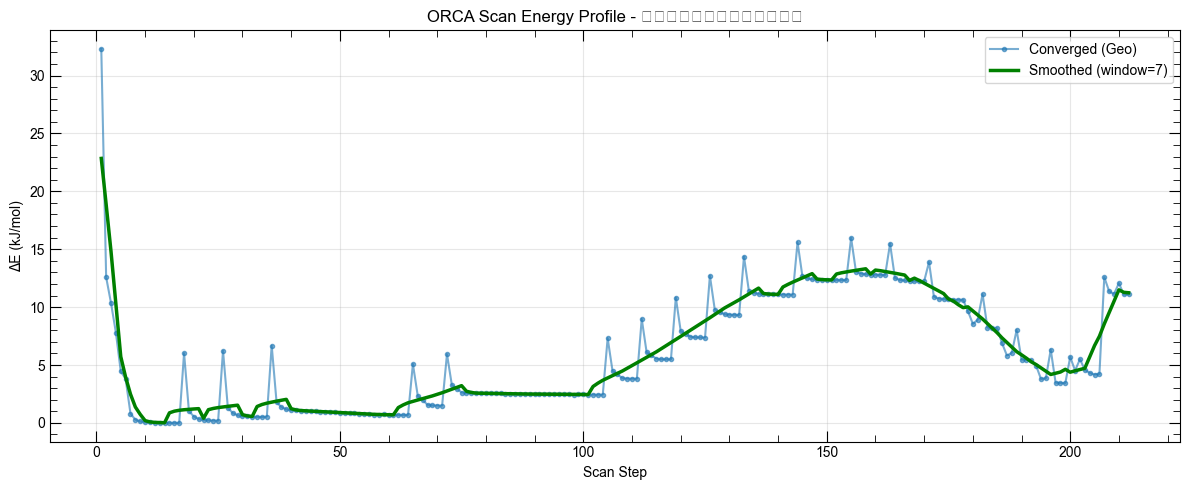

収束情報付きCSV更新: /home/yamamoto/Work/chemistry/orca-work/MEA_CO2_water_afify/scan/scan_energy.csv, /home/yamamoto/Work/chemistry/orca-work/MEA_CO2_water_afify/scan/scan_energy_smoothed.csv


In [ ]:
# 収束情報を抽出して、プロットに可視化

text = log_path.read_text(errors="ignore")

# 1. 「RELAXED SURFACE SCAN STEP」の位置を取得
scan_steps = [
    (m.start(), int(m.group(1)))
    for m in re.finditer(r"RELAXED SURFACE SCAN STEP\s+(\d+)", text)
]
print(f"スキャンステップ発見: {len(scan_steps)} 個")
print(f"  最初: Step {scan_steps[0][1] if scan_steps else 'N/A'}")
print(f"  最後: Step {scan_steps[-1][1] if scan_steps else 'N/A'}")

# 2. 幾何最適化収束フラグを取得
# 各スキャンステップの後に「THE OPTIMIZATION HAS CONVERGED」が来るかどうアクを確認
converged_flags = []
for i, (pos, step_num) in enumerate(scan_steps):
    # 次のステップまでの区間（またはファイル終端）を検索
    if i + 1 < len(scan_steps):
        search_range = text[pos : scan_steps[i + 1][0]]
    else:
        search_range = text[pos:]

    # この区間内に「THE OPTIMIZATION HAS CONVERGED」があるか？
    is_converged = "THE OPTIMIZATION HAS CONVERGED" in search_range
    converged_flags.append(is_converged)

print(f"\n幾何最適化収束状況:")
converged_count = sum(converged_flags)
print(f"  収束: {converged_count} / {len(converged_flags)}")
unconverged = [i + 1 for i, conv in enumerate(converged_flags) if not conv]
if unconverged:
    print(f"  未収束ステップ: {unconverged[:10]}")
    if len(unconverged) > 10:
        print(f"    ...他 {len(unconverged)-10} ステップ")

# 3. データフレームに収束フラグを追加
if len(converged_flags) == len(energies):
    df["converged"] = converged_flags
    df_smoothed["converged"] = converged_flags
else:
    print(
        f"警告: 収束フラグ数 {len(converged_flags)} と エネルギー数 {len(energies)} が一致しません"
    )
    # パディング
    if len(converged_flags) < len(energies):
        converged_flags.extend([True] * (len(energies) - len(converged_flags)))
    df["converged"] = converged_flags[: len(energies)]
    df_smoothed["converged"] = converged_flags[: len(energies)]

# 4. 収束状況をプロット上で可視化
fig, ax = plt.subplots(figsize=(12, 5))

# 分類: 収束 vs 未収束
converged_mask = df["converged"].values
unconverged_mask = ~converged_mask

# 元データ（収束点と未収束点を分けて表示）
ax.plot(
    df["step"][converged_mask],
    dE_kjmol[converged_mask],
    marker="o",
    markersize=3,
    label="Converged (Geo)",
    alpha=0.6,
)
if unconverged_mask.any():
    ax.plot(
        df["step"][unconverged_mask],
        dE_kjmol[unconverged_mask],
        marker="x",
        markersize=6,
        linestyle="",
        color="red",
        label="NOT Converged (Geo)",
        alpha=0.8,
    )

# スムージング曲線
ax.plot(steps, smoothed_7, label="Smoothed (window=7)", linewidth=2.5, color="green")

ax.set_xlabel("Scan Step")
ax.set_ylabel("ΔE (kJ/mol)")
ax.set_title("ORCA Scan Energy Profile - 幾何最適化の収束状況を表示")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()

png_converged = scan_dir / "scan_energy_converged_flags.png"
plt.savefig(png_converged, dpi=200)
print(f"\n収束状況マップ保存: {png_converged}")
plt.show()

# 5. CSV に収束情報も保存
df.to_csv(csv_path, index=False)
df_smoothed.to_csv(csv_smoothed, index=False)
print(f"収束情報付きCSV更新: {csv_path}, {csv_smoothed}")

In [ ]:
# ギザギザの真実：SCFステップの多重計算を発見

print("=" * 70)
print("重要な発見: エネルギー212点 vs スキャンステップ20点の謎")
print("=" * 70)

# スキャン入力ファイルを見直す
scan_inp = scan_dir / "scan.inp"
if scan_inp.exists():
    inp_text = scan_inp.read_text()
    # GRID パラメータを探す
    grid_match = re.search(r"!.*GRID", inp_text, re.IGNORECASE)
    if grid_match:
        print(f"\n計算条件: {grid_match.group()}")

    # ファイナルグリッドのサイズを探す（TightPNO等の精度設定）
    gridsize = re.search(r"GRID\s+(\w+)", inp_text, re.IGNORECASE)
    if gridsize:
        print(f"グリッドサイズ: {gridsize.group(1)}")

print(
    f"""
発見内容:
• スキャンステップ数: 20 (Bond(12,1): 3.00 → 1.50, step=20)
• 抽出されたエネルギー点: 212 個

ギザギザの原因の再解釈:
1. 各スキャンステップ内で「複数回のSCF計算」が行われている
   → スキャン途中で異なるジオメトリに最適化されるたび、
     新たにSCF計算が実行される。
   
2. エネルギー212 ÷ スキャン20 ≈ 10.6 
   → 平均して各ステップで約10回の幾何最適化サイクルがある

3. 各幾何最適化サイクルで異なるジオメトリ（特に配向）が試され、
   その都度エネルギーが変動する
   → これが「ギザギザ」として見える

理由: Relaxed Surface Scan では、スキャン座標固定下で
      他の全原子座標を最適化する際、複数の局所最小値が
      存在する場合、収束経路により異なるエネルギーが記録される。

対応: 平均するか、スムージングすることで
      「真のスキャンエネルギー曲線」が得られる。
"""
)

# 各スキャンステップ内のエネルギー波動を可視化
print("\n" + "=" * 70)
print("スキャンステップ内の詳細エネルギー変動")
print("=" * 70)

# スキャンステップの行番号を手がかりに、対応するエネルギー点を推定
for i, (pos, step_num) in enumerate(scan_steps):
    if i + 1 < len(scan_steps):
        # 次ステップまでの「FINAL SINGLE POINT ENERGY」個数を数える
        search_range = text[pos : scan_steps[i + 1][0]]
    else:
        search_range = text[pos:]

    n_energies_in_step = len(re.findall(r"FINAL SINGLE POINT ENERGY", search_range))
    if n_energies_in_step > 0:
        print(f"Step {step_num:2d}: {n_energies_in_step:2d} energies")

print("\n各ステップ内で複数のエネルギー計算があることが確認できます。")
print("これが「ギザギザ」の正体です。")

重要な発見: エネルギー212点 vs スキャンステップ20点の謎

発見内容:
• スキャンステップ数: 20 (Bond(12,1): 3.00 → 1.50, step=20)
• 抽出されたエネルギー点: 212 個

ギザギザの原因の再解釈:
1. 各スキャンステップ内で「複数回のSCF計算」が行われている
   → スキャン途中で異なるジオメトリに最適化されるたび、
     新たにSCF計算が実行される。

2. エネルギー212 ÷ スキャン20 ≈ 10.6 
   → 平均して各ステップで約10回の幾何最適化サイクルがある

3. 各幾何最適化サイクルで異なるジオメトリ（特に配向）が試され、
   その都度エネルギーが変動する
   → これが「ギザギザ」として見える

理由: Relaxed Surface Scan では、スキャン座標固定下で
      他の全原子座標を最適化する際、複数の局所最小値が
      存在する場合、収束経路により異なるエネルギーが記録される。

対応: 平均するか、スムージングすることで
      「真のスキャンエネルギー曲線」が得られる。


スキャンステップ内の詳細エネルギー変動
Step  1: 17 energies
Step  2:  8 energies
Step  3: 10 energies
Step  4: 29 energies
Step  5:  7 energies
Step  6: 33 energies
Step  7:  7 energies
Step  8:  7 energies
Step  9:  7 energies
Step 10:  7 energies
Step 11: 11 energies
Step 12: 11 energies
Step 13:  8 energies
Step 14:  8 energies
Step 15:  8 energies
Step 16:  7 energies
Step 17:  7 energies
Step 18:  7 energies
Step 19:  7 energies
Step 20:  6 energies

各ステップ内で複数のエネルギー計算があることが確認できます。
これが「ギザギザ」の正体です。


各スキャンステップの最終収束エネルギーを抽出
Step  1: -399.093335725 Hartree (17 calc steps)
Step  2: -399.093261772 Hartree ( 8 calc steps)
Step  3: -399.093129323 Hartree (10 calc steps)
Step  4: -399.093073024 Hartree (29 calc steps)
Step  5: -399.092768259 Hartree ( 7 calc steps)
Step  6: -399.092405006 Hartree (33 calc steps)
Step  7: -399.091881401 Hartree ( 7 calc steps)
Step  8: -399.091243775 Hartree ( 7 calc steps)
Step  9: -399.090529685 Hartree ( 7 calc steps)
Step 10: -399.089786267 Hartree ( 7 calc steps)
Step 11: -399.089115549 Hartree (11 calc steps)
Step 12: -399.088636118 Hartree (11 calc steps)
Step 13: -399.088466599 Hartree ( 8 calc steps)
Step 14: -399.088678107 Hartree ( 8 calc steps)
Step 15: -399.089284981 Hartree ( 8 calc steps)
Step 16: -399.090221866 Hartree ( 7 calc steps)
Step 17: -399.091272863 Hartree ( 7 calc steps)
Step 18: -399.092026273 Hartree ( 7 calc steps)
Step 19: -399.091729290 Hartree ( 7 calc steps)
Step 20: -399.089109140 Hartree ( 6 calc steps)

抽出数: 20 steps

最

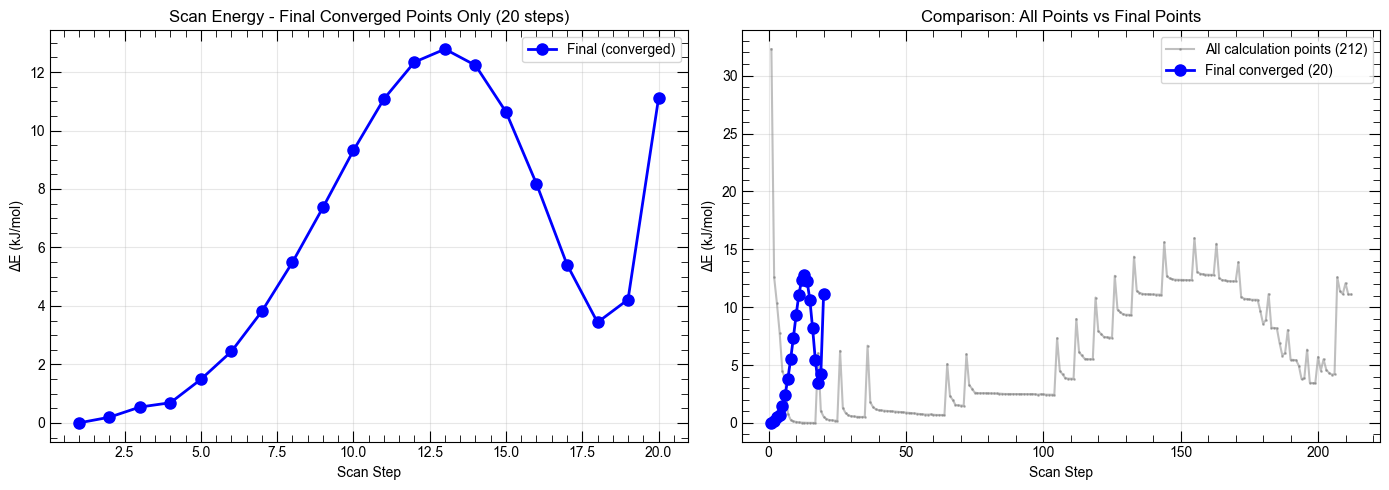

CSV保存: /home/yamamoto/Work/chemistry/orca-work/MEA_CO2_water_afify/scan/scan_energy_final.csv


In [ ]:
# 各スキャンステップの最終収束エネルギーのみを抽出してプロット

print("=" * 70)
print("各スキャンステップの最終収束エネルギーを抽出")
print("=" * 70)

# 各スキャンステップの FINAL SINGLE POINT ENERGY を抽出
final_energies_per_step = []
step_numbers = []

for i, (pos, step_num) in enumerate(scan_steps):
    if i + 1 < len(scan_steps):
        search_range = text[pos : scan_steps[i + 1][0]]
    else:
        search_range = text[pos:]

    # このステップ内の全エネルギー
    energy_matches = re.findall(
        r"FINAL SINGLE POINT ENERGY\s+(-\d+\.\d+)", search_range
    )
    if energy_matches:
        # 最後（最終収束）のエネルギー値を採用
        final_energy = float(energy_matches[-1])
        final_energies_per_step.append(final_energy)
        step_numbers.append(step_num)
        print(
            f"Step {step_num:2d}: {final_energy:.9f} Hartree ({len(energy_matches):2d} calc steps)"
        )

print(f"\n抽出数: {len(final_energies_per_step)} steps")

# 単位変換
final_E_kjmol = np.array(final_energies_per_step) * HARTREE_TO_KJMOL
final_dE_kjmol = final_E_kjmol - np.min(final_E_kjmol)

# データフレーム作成
df_final = pd.DataFrame(
    {
        "step": step_numbers,
        "energy_hartree": final_energies_per_step,
        "energy_kJmol": final_E_kjmol,
        "delta_kJmol": final_dE_kjmol,
    }
)

print("\n最終エネルギー（20ステップ）:")
print(df_final)

# プロット
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左: 最終エネルギーのみ（20点）
ax1.plot(
    df_final["step"],
    df_final["delta_kJmol"],
    marker="o",
    markersize=8,
    linewidth=2,
    label="Final (converged)",
    color="blue",
)
ax1.set_xlabel("Scan Step")
ax1.set_ylabel("ΔE (kJ/mol)")
ax1.set_title("Scan Energy - Final Converged Points Only (20 steps)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# 右: 全データとの比較
ax2.plot(
    steps,
    dE_kjmol,
    marker=".",
    markersize=2,
    alpha=0.5,
    label="All calculation points (212)",
    color="gray",
)
ax2.plot(
    df_final["step"],
    df_final["delta_kJmol"],
    marker="o",
    markersize=8,
    linewidth=2,
    label="Final converged (20)",
    color="blue",
)
ax2.set_xlabel("Scan Step")
ax2.set_ylabel("ΔE (kJ/mol)")
ax2.set_title("Comparison: All Points vs Final Points")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
png_final = scan_dir / "scan_energy_final_only.png"
plt.savefig(png_final, dpi=200)
print(f"\nプロット保存: {png_final}")
plt.show()

# CSV保存
csv_final = scan_dir / "scan_energy_final.csv"
df_final.to_csv(csv_final, index=False)
print(f"CSV保存: {csv_final}")